<a href="https://colab.research.google.com/github/Rajarajeswari77-ai/Raji/blob/main/Project_1_IRIS_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Iris dataset
df = sns.load_dataset('iris')
print("Original shape:", df.shape)
df.head()

Original shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
print(df.info())
print("\nMissing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

# Statistical summary to spot potential outliers
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

Missing values per column:
 sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Duplicate rows: 1
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.0

In [4]:
# Create a copy for cleaning
df_clean = df.copy()

# If missing values existed, we would fill them like this:
# df_clean.fillna(df_clean.median(), inplace=True)
# Or for categorical columns: df_clean['species'].fillna(df_clean['species'].mode()[0], inplace=True)

print("Missing values after handling:", df_clean.isnull().sum().sum())  # should be 0

Missing values after handling: 0


In [5]:
duplicates_before = df_clean.duplicated().sum()
df_clean.drop_duplicates(inplace=True)
print(f"Duplicates removed: {duplicates_before} → {df_clean.duplicated().sum()}")

Duplicates removed: 1 → 0


In [6]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    return outliers

for col in ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']:
    out = detect_outliers_iqr(df_clean, col)
    print(f"{col}: {len(out)} outliers detected")

sepal_length: 0 outliers detected
sepal_width: 4 outliers detected
petal_length: 0 outliers detected
petal_width: 0 outliers detected


In [9]:
# Example: capping outliers for sepal_width (if any)
def cap_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    data[column] = data[column].clip(lower, upper)
    return data
df_clean = cap_outliers(df_clean, 'sepal_width')

/tmp/ipykernel_1361/1772427100.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='species', y='sepal_width', palette='pastel', ax=ax4)
/tmp/ipykernel_1361/1772427100.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clean, x='species', y='petal_length', palette='coolwarm', ax=ax5)


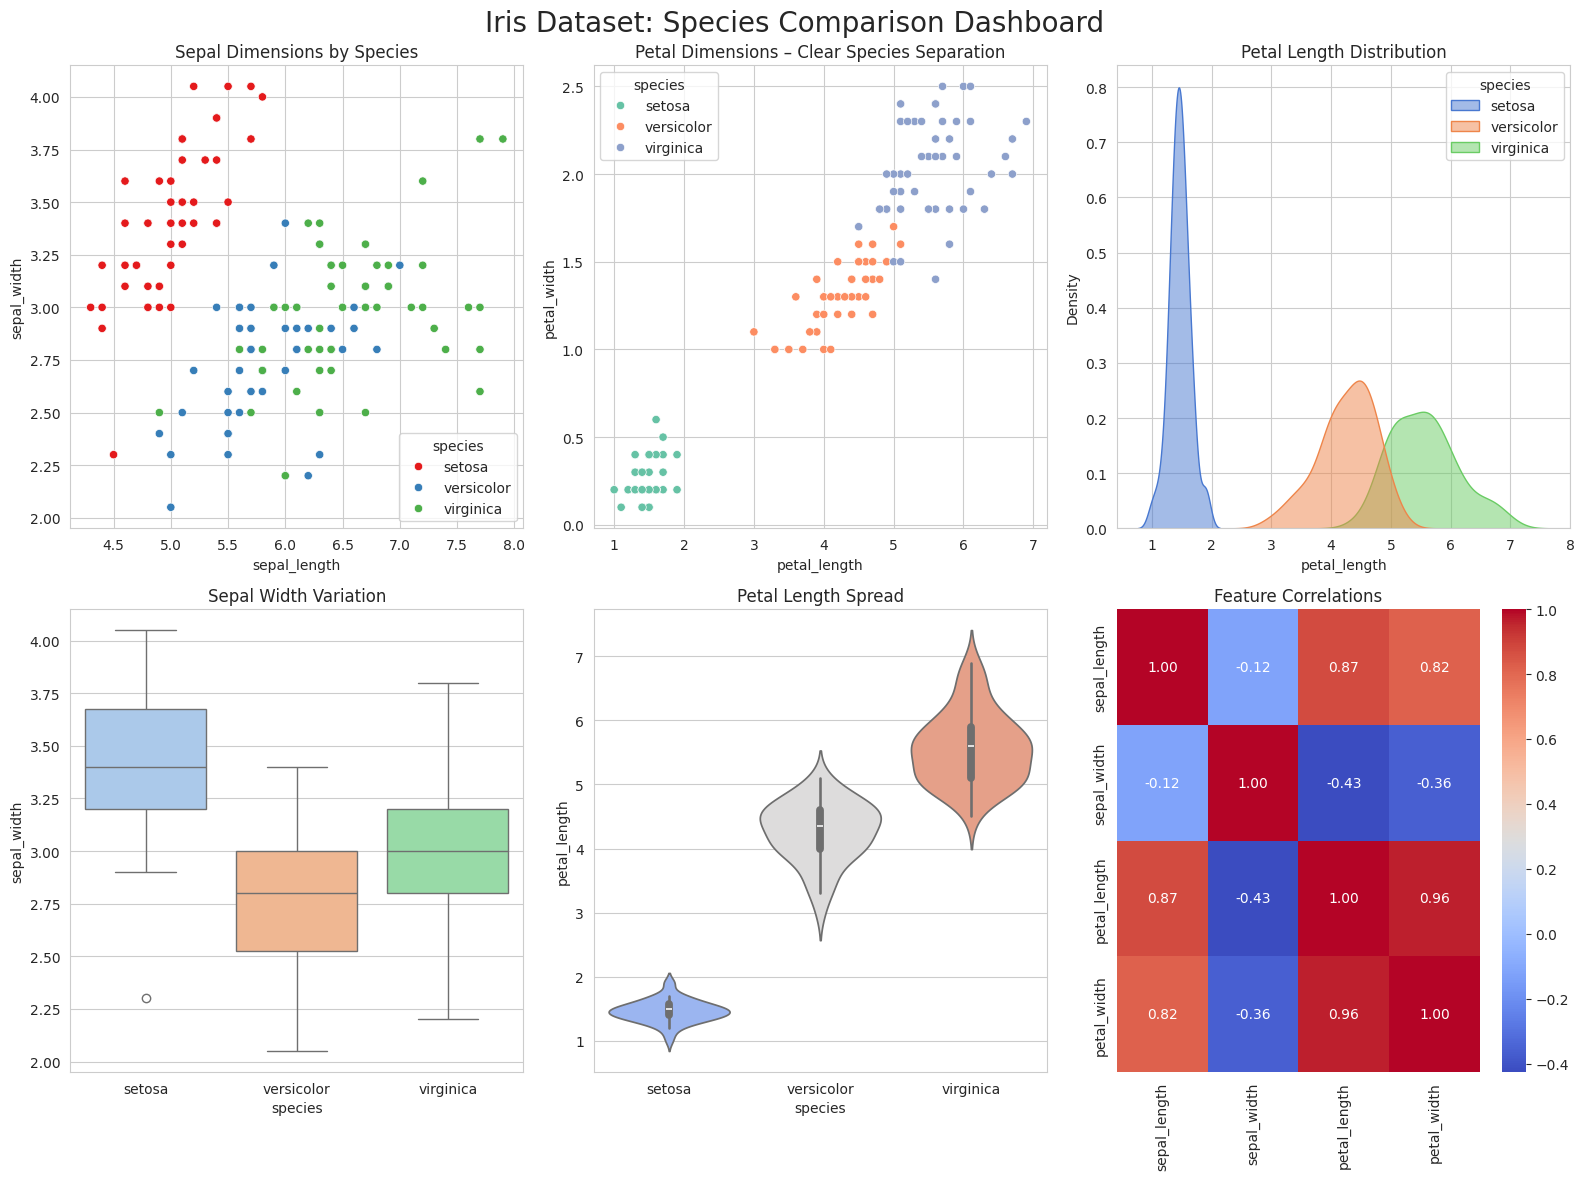

In [10]:
# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 10)

fig = plt.figure(figsize=(16, 12))
fig.suptitle('Iris Dataset: Species Comparison Dashboard', fontsize=20, y=0.98)

# 1. Pairplot (shows overall separation)
# We'll use a smaller version inside the dashboard by creating a subplot
# But pairplot is large – we put it as a separate saved figure later.
# Instead, show 5 targeted plots:

# 2. Sepal Length vs Sepal Width by species
ax1 = fig.add_subplot(2, 3, 1)
sns.scatterplot(data=df_clean, x='sepal_length', y='sepal_width', hue='species', palette='Set1', ax=ax1)
ax1.set_title('Sepal Dimensions by Species')

# 3. Petal Length vs Petal Width by species (best separation)
ax2 = fig.add_subplot(2, 3, 2)
sns.scatterplot(data=df_clean, x='petal_length', y='petal_width', hue='species', palette='Set2', ax=ax2)
ax2.set_title('Petal Dimensions – Clear Species Separation')

# 4. Distribution of Petal Length (KDE)
ax3 = fig.add_subplot(2, 3, 3)
sns.kdeplot(data=df_clean, x='petal_length', hue='species', fill=True, alpha=0.5, palette='muted', ax=ax3)
ax3.set_title('Petal Length Distribution')

# 5. Boxplot – Sepal Width by species
ax4 = fig.add_subplot(2, 3, 4)
sns.boxplot(data=df_clean, x='species', y='sepal_width', palette='pastel', ax=ax4)
ax4.set_title('Sepal Width Variation')

# 6. Violin plot – Petal Length by species
ax5 = fig.add_subplot(2, 3, 5)
sns.violinplot(data=df_clean, x='species', y='petal_length', palette='coolwarm', ax=ax5)
ax5.set_title('Petal Length Spread')

# 7. Correlation heatmap of numeric features
ax6 = fig.add_subplot(2, 3, 6)
numeric_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
corr = df_clean[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', ax=ax6)
ax6.set_title('Feature Correlations')

plt.tight_layout()
plt.show()

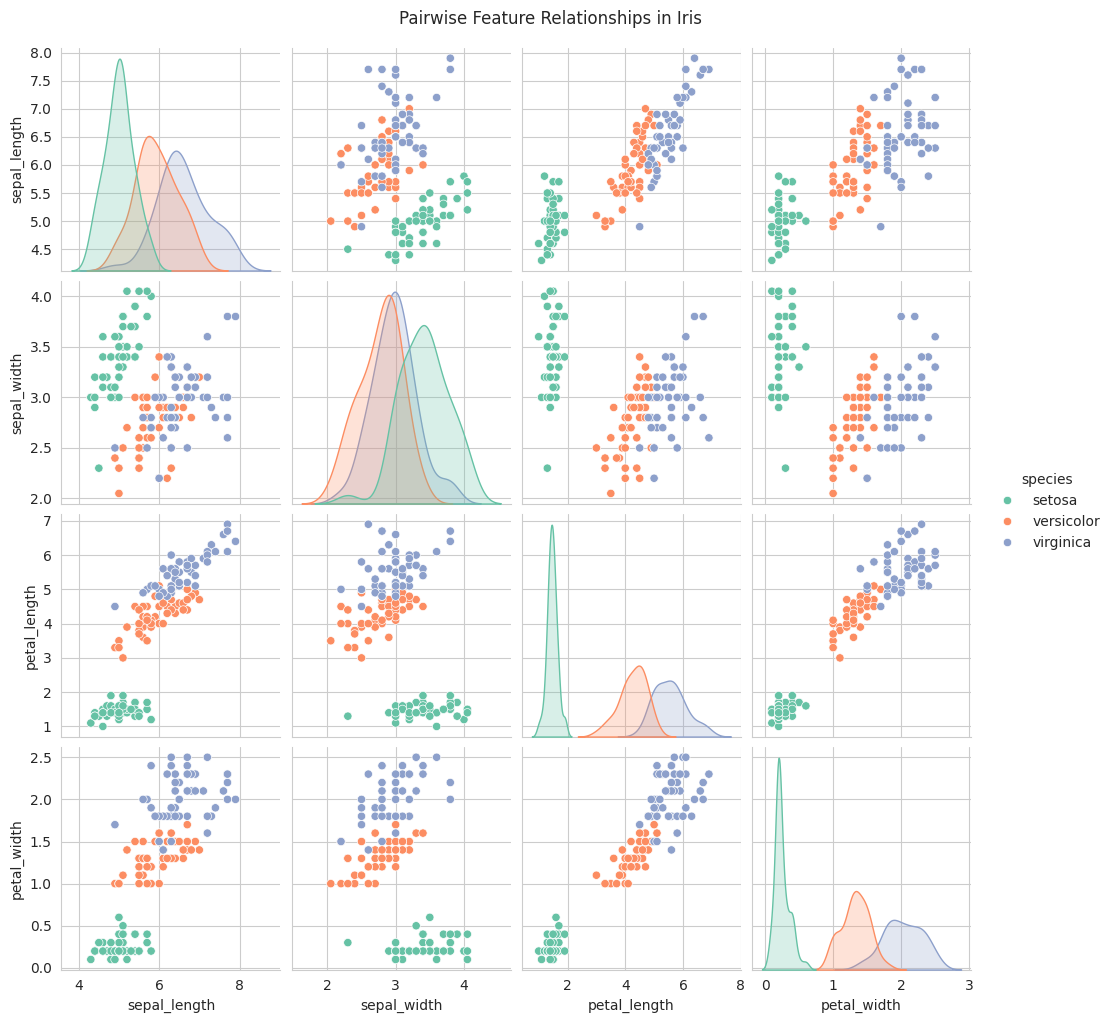

In [11]:
# This is great for showing all pairwise relationships
sns.pairplot(df_clean, hue='species', palette='Set2')
plt.suptitle('Pairwise Feature Relationships in Iris', y=1.02)
plt.savefig('iris_pairplot.png', dpi=300)
plt.show()